# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Step 2: Load the Dataset

In [2]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

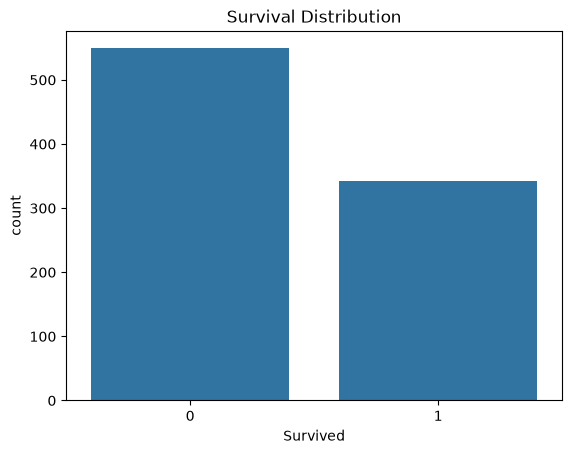

In [7]:
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

In [8]:
df["Sex"].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [9]:
df["Embarked"].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [10]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [13]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [15]:
df["Embarked"].unique()

<ArrowStringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [16]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

# Step 3: Separate Features and Target

In [17]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [18]:
print(X.shape)
print(y.shape)

(891, 8)
(891,)


# Step 4: Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print(y.value_counts(normalize=True))

print()

print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


# Step 5: Build the Pipelines

In [21]:
dt_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

In [22]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

In [23]:
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

In [24]:
dt_pipeline.fit(X_train, y_train)

knn_pipeline.fit(X_train, y_train)

nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pclass','Age','SibSp',...,'Sex_male','Embarked_Q','Embarked_S']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
dt_pred = dt_pipeline.predict(X_test)

knn_pred = knn_pipeline.predict(X_test)

nb_pred = nb_pipeline.predict(X_test)

In [26]:
def evaluate_model(model_name, y_true, y_pred):
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(
        confusion_matrix(y_true, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Decision Tree
Accuracy : 0.8212
Precision: 0.7937
Recall   : 0.7246
F1 Score : 0.7576

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



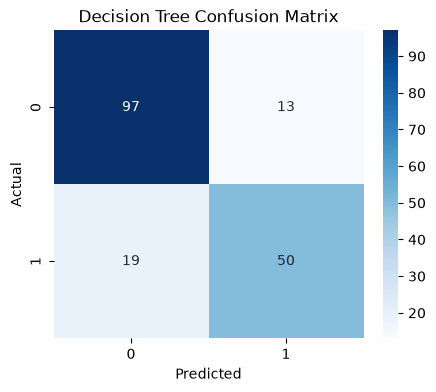

In [27]:
evaluate_model("Decision Tree", y_test, dt_pred)

k-Nearest Neighbors
Accuracy : 0.8156
Precision: 0.8000
Recall   : 0.6957
F1 Score : 0.7442

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



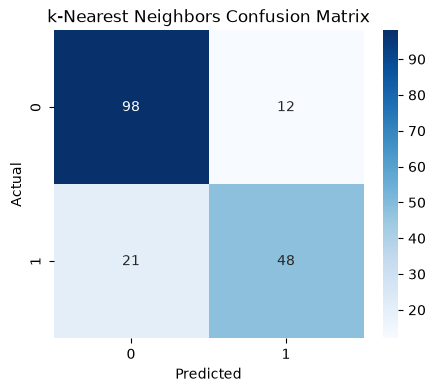

In [28]:
evaluate_model("k-Nearest Neighbors", y_test, knn_pred)

Gaussian Naive Bayes
Accuracy : 0.7821
Precision: 0.7273
Recall   : 0.6957
F1 Score : 0.7111

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



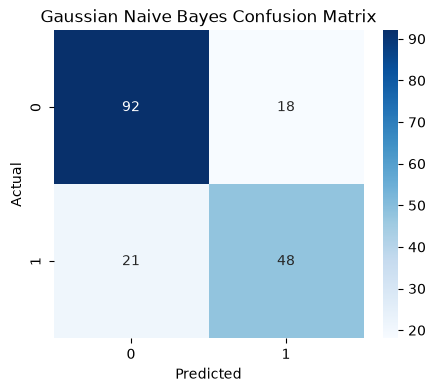

In [29]:
evaluate_model("Gaussian Naive Bayes", y_test, nb_pred)

In [30]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "kNN",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nb_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, nb_pred)
    ],
    "Recall": [
        recall_score(y_test, dt_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, nb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, nb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.821229,0.793651,0.724638,0.757576
1,kNN,0.815642,0.800000,0.695652,0.744186
2,Naive Bayes,0.782123,0.727273,0.695652,0.711111


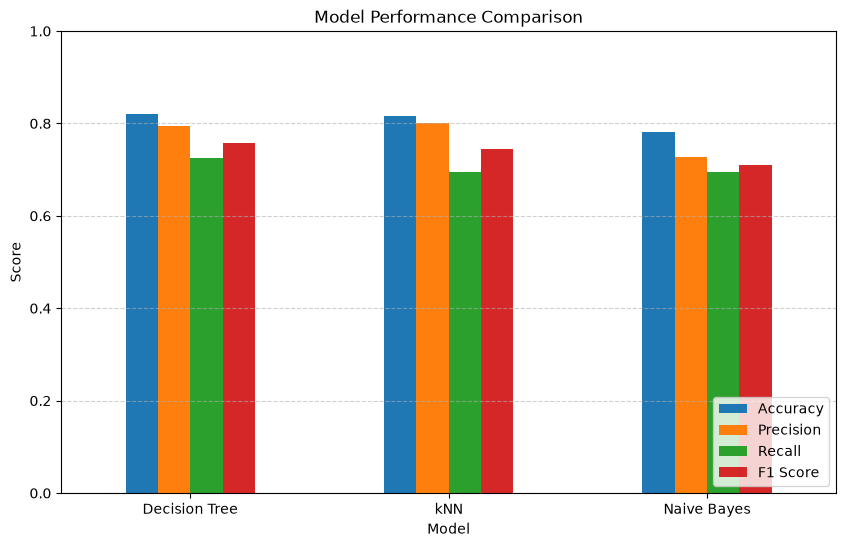

In [31]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()